# EDA ampliado: sesiones con mayor probabilidad de compra

**Autor:** Andrés Bautista  
**Entrega:** 2

Este análisis amplía el EDA de la primera entrega para responder directamente la pregunta de negocio: **¿qué sesiones presentan mayor probabilidad de finalizar en una compra?**

El alcance se concentra en conversión, contexto comercial, profundidad de navegación, abandono y `PageValues`. Para preservar la trazabilidad del equipo, no repite los análisis desarrollados por Janer sobre sesiones duplicadas, duraciones extremas ni contexto tecnológico/fuente de tráfico (`OperatingSystems`, `Browser`, `Region` y `TrafficType`).

Las asociaciones encontradas son descriptivas y predictivas; no se interpretan como efectos causales.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from online_shoppers.data import load_dataset

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data/raw/online_shoppers_intention.csv'
FIGURES_PATH = ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
PURCHASE_COLOR = '#2563eb'
NO_PURCHASE_COLOR = '#94a3b8'
MONTH_ORDER = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

/Users/mijo/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/7j/8pjk2vb17ngf_x0yj8t5bh3h0000gn/T/matplotlib-kigpauzd because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
sessions = load_dataset(DATA_PATH)
assert sessions.shape == (12_330, 18)
assert sessions['Revenue'].dtype == bool
sessions.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Ruta del análisis

1. Cuantificar el desbalance de `Revenue` y comparar la conversión por tipo de visitante, mes y fin de semana.
2. Evaluar cómo cambia la conversión con la profundidad y duración de la navegación.
3. Examinar la relación entre abandono (`BounceRates`, `ExitRates`) y compra.
4. Analizar `PageValues`, incluyendo su disponibilidad al momento de inferencia.
5. Sintetizar hallazgos e implicaciones para el modelamiento.

## 1. Conversión y contexto comercial

Además del porcentaje observado, se reporta el número de sesiones y un intervalo de confianza de Wilson al 95 %. Esto evita sobreinterpretar tasas calculadas sobre grupos pequeños.

In [3]:
def conversion_table(frame, group, order=None):
    table = (
        frame.groupby(group, observed=True)['Revenue']
        .agg(sessions='size', purchases='sum', conversion_rate='mean')
    )
    if order is not None:
        table = table.reindex(order)

    z = 1.96
    n = table['sessions'].astype(float)
    p = table['conversion_rate']
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p * (1 - p) / n) + z**2 / (4 * n**2)) / denominator
    table['ci_low'] = (center - margin).clip(0, 1)
    table['ci_high'] = (center + margin).clip(0, 1)
    return table


def plot_conversion(axis, table, title, color=PURCHASE_COLOR):
    positions = np.arange(len(table))
    rates = table['conversion_rate'].to_numpy()
    errors = np.vstack([
        rates - table['ci_low'].to_numpy(),
        table['ci_high'].to_numpy() - rates,
    ])
    axis.bar(positions, rates, color=color, alpha=0.9)
    axis.errorbar(positions, rates, yerr=errors, fmt='none', color='#0f172a', capsize=3)
    axis.set_xticks(positions, [str(value).replace('_', ' ') for value in table.index])
    axis.set_title(title)
    axis.set_ylabel('Tasa de conversión')
    axis.set_ylim(0, max(0.30, float(table['ci_high'].max()) * 1.15))
    axis.tick_params(axis='x', rotation=30)
    axis.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')

In [4]:
target_balance = (
    sessions['Revenue'].value_counts()
    .rename(index={False: 'No compra', True: 'Compra'})
    .rename('sessions')
    .to_frame()
)
target_balance['share'] = target_balance['sessions'] / len(sessions)
visitor_conversion = conversion_table(
    sessions, 'VisitorType', ['New_Visitor', 'Returning_Visitor', 'Other']
)
month_conversion = conversion_table(sessions, 'Month', MONTH_ORDER)
weekend_conversion = conversion_table(sessions, 'Weekend', [False, True]).rename(
    index={False: 'Entre semana', True: 'Fin de semana'}
)

display(target_balance.style.format({'share': '{:.2%}'}))
display(visitor_conversion.style.format({'conversion_rate': '{:.2%}', 'ci_low': '{:.2%}', 'ci_high': '{:.2%}'}))
display(month_conversion.style.format({'conversion_rate': '{:.2%}', 'ci_low': '{:.2%}', 'ci_high': '{:.2%}'}))
display(weekend_conversion.style.format({'conversion_rate': '{:.2%}', 'ci_low': '{:.2%}', 'ci_high': '{:.2%}'}))

,sessions,share
Revenue,,
No compra,10422,84.53%
Compra,1908,15.47%


,sessions,purchases,conversion_rate,ci_low,ci_high
VisitorType,,,,,
New_Visitor,1694,422,24.91%,22.91%,27.03%
Returning_Visitor,10551,1470,13.93%,13.28%,14.61%
Other,85,16,18.82%,11.93%,28.41%


,sessions,purchases,conversion_rate,ci_low,ci_high
Month,,,,,
Feb,184,3,1.63%,0.56%,4.68%
Mar,1907,192,10.07%,8.80%,11.50%
May,3364,365,10.85%,9.84%,11.95%
June,288,29,10.07%,7.10%,14.09%
Jul,432,66,15.28%,12.19%,18.98%
Aug,433,76,17.55%,14.26%,21.42%
Sep,448,86,19.20%,15.82%,23.10%
Oct,549,115,20.95%,17.75%,24.55%
Nov,2998,760,25.35%,23.83%,26.94%


,sessions,purchases,conversion_rate,ci_low,ci_high
Weekend,,,,,
Entre semana,9462,1409,14.89%,14.19%,15.62%
Fin de semana,2868,499,17.40%,16.06%,18.83%


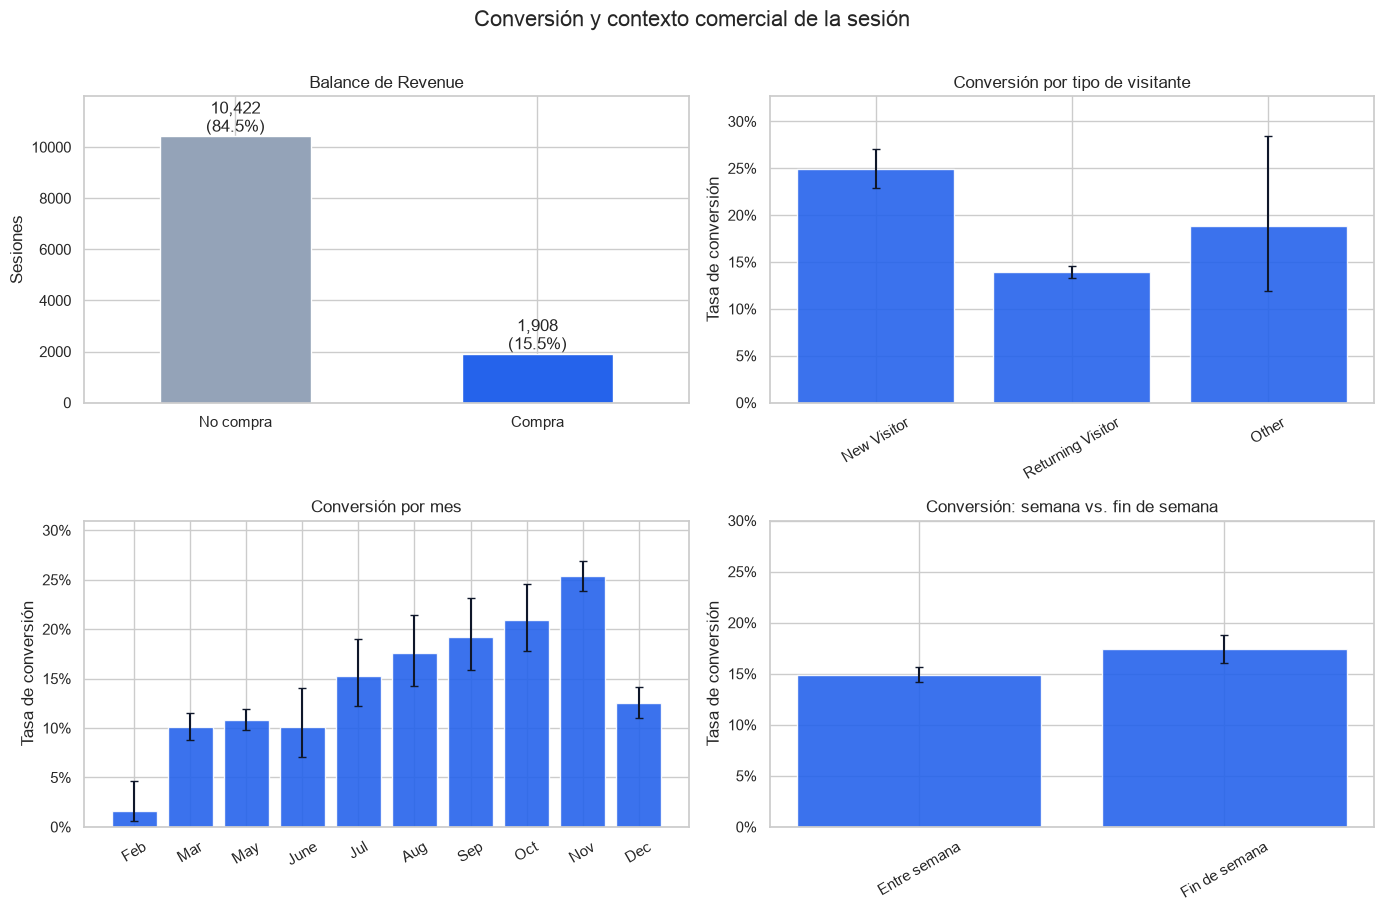

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
target_balance['sessions'].plot.bar(
    ax=axes[0, 0], color=[NO_PURCHASE_COLOR, PURCHASE_COLOR], rot=0
)
axes[0, 0].set(title='Balance de Revenue', xlabel='', ylabel='Sesiones')
for position, (count, share) in enumerate(zip(target_balance['sessions'], target_balance['share'])):
    axes[0, 0].text(position, count + 180, f'{count:,}\n({share:.1%})', ha='center')
axes[0, 0].set_ylim(0, target_balance['sessions'].max() * 1.15)

plot_conversion(axes[0, 1], visitor_conversion, 'Conversión por tipo de visitante')
plot_conversion(axes[1, 0], month_conversion, 'Conversión por mes')
plot_conversion(axes[1, 1], weekend_conversion, 'Conversión: semana vs. fin de semana')
fig.suptitle('Conversión y contexto comercial de la sesión', fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'andres_eda_conversion_context.png', dpi=160, bbox_inches='tight')
plt.show()

### Hallazgos e implicaciones

- Solo **1.908 de 12.330 sesiones (15,47 %)** terminan en compra. Por cada sesión positiva hay 5,46 negativas; por ello, la exactitud aislada puede ser engañosa y conviene priorizar PR-AUC, precision, recall y F1 en el modelamiento.
- Los visitantes nuevos convierten al **24,91 %**, frente al **13,93 %** de los recurrentes (una razón descriptiva de 1,79). `VisitorType` aporta una señal útil, aunque el modelo debe aprenderla junto con el comportamiento de la sesión y no como regla aislada.
- Noviembre presenta la tasa más alta (**25,35 %**) y febrero la más baja (**1,63 %**). La amplitud entre meses sugiere estacionalidad, pero los tamaños de muestra cambian sustancialmente; la variable debe validarse fuera de muestra.
- Las sesiones de fin de semana convierten al **17,40 %** frente al **14,89 %** entre semana. La diferencia es moderada: `Weekend` puede complementar otras señales, pero no basta por sí sola para identificar una compra.

## 2. Profundidad de navegación frente a Revenue

Para cada variable se separan las sesiones sin actividad y se dividen las observaciones positivas en tres bandas basadas en terciles. Así se estudia toda la distribución sin duplicar el análisis de Janer sobre duraciones extremas. Las bandas son descriptivas y se recalcularían únicamente sobre datos de entrenamiento dentro de un pipeline predictivo.

In [6]:
def activity_band(series):
    positive = series[series > 0]
    terciles = sorted({
        float(positive.quantile(1 / 3)),
        float(positive.quantile(2 / 3)),
    })
    bins = [-np.inf, 0, *terciles, np.inf]
    labels = ['Sin actividad', 'Actividad baja', 'Actividad media', 'Actividad alta']
    return pd.cut(series, bins=bins, labels=labels[: len(bins) - 1], include_lowest=True)


navigation_columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
]
navigation_tables = {
    column: conversion_table(
        sessions.assign(ActivityBand=activity_band(sessions[column])),
        'ActivityBand',
    )
    for column in navigation_columns
}
navigation_summary = pd.concat(navigation_tables, names=['variable', 'activity_band'])
display(navigation_summary.style.format({
    'conversion_rate': '{:.2%}', 'ci_low': '{:.2%}', 'ci_high': '{:.2%}'
}))

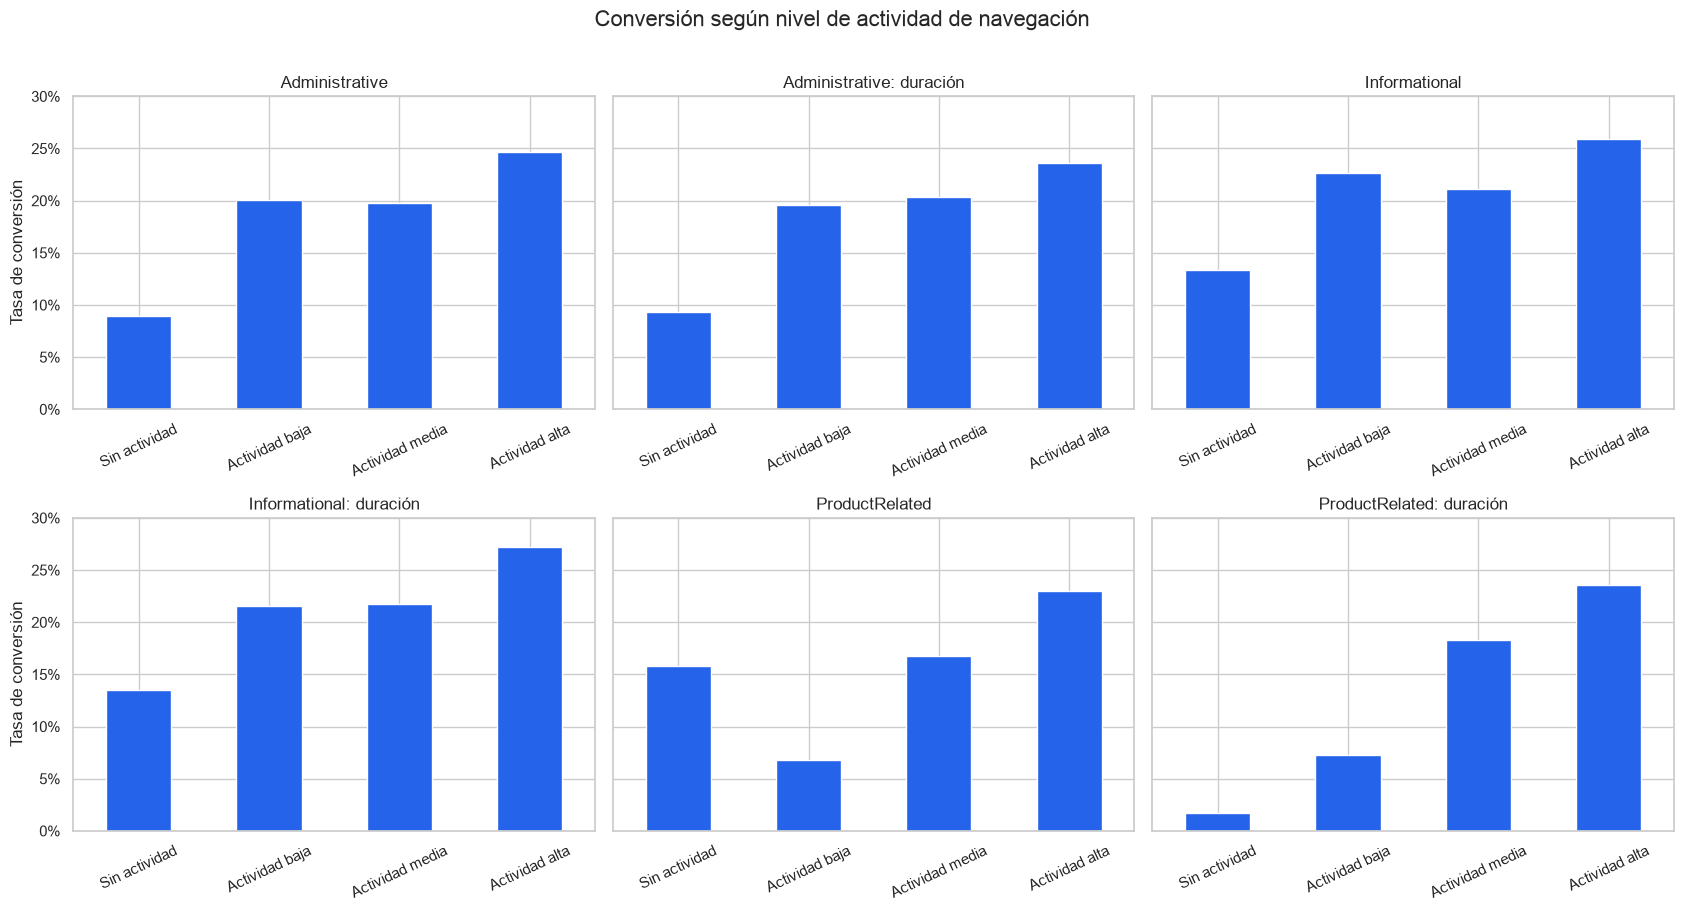

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
for axis, column in zip(axes.flat, navigation_columns):
    table = navigation_tables[column]
    table['conversion_rate'].plot.bar(ax=axis, color=PURCHASE_COLOR, rot=25)
    axis.set_title(column.replace('_Duration', ': duración'))
    axis.set_xlabel('')
    axis.set_ylabel('Tasa de conversión')
    axis.set_ylim(0, 0.30)
    axis.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
fig.suptitle('Conversión según nivel de actividad de navegación', fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'andres_eda_navigation_behavior.png', dpi=160, bbox_inches='tight')
plt.show()

### Hallazgos de navegación

- La ausencia de actividad administrativa e informativa se asocia con conversiones de **8,91 %** y **13,35 %**, respectivamente; en las bandas altas las tasas suben a **24,63 %** y **25,87 %**.
- La duración informativa muestra el gradiente más claro de ese bloque: **13,53 %** sin actividad frente a **27,18 %** en la banda alta. Esto sugiere que consultar contenido de apoyo puede acompañar una intención de compra más desarrollada.
- La duración en páginas de producto aumenta desde **1,72 %** sin tiempo registrado hasta **23,56 %** en la banda alta. El patrón respalda incluir profundidad y duración de navegación, idealmente con transformaciones logarítmicas por su asimetría.
- Las relaciones no son perfectamente lineales en todas las variables. Los modelos con interacciones y no linealidades pueden capturar estos cambios mejor que una regla de corte manual.

## 3. Abandono y probabilidad observada de compra

`BounceRates` aproxima sesiones que abandonan tras una sola página y `ExitRates` la frecuencia de salida desde las páginas visitadas. Se usan bandas interpretables para comprobar si tasas altas de abandono coinciden con menor conversión.

In [8]:
bounce_band = pd.cut(
    sessions['BounceRates'],
    bins=[-1e-12, 0, 0.01, 0.03, 0.07, 0.201],
    labels=['0', '(0, 1%]', '(1%, 3%]', '(3%, 7%]', '> 7%'],
    include_lowest=True,
)
exit_band = pd.cut(
    sessions['ExitRates'],
    bins=[-1e-12, 0.01, 0.025, 0.05, 0.10, 0.201],
    labels=['≤ 1%', '(1%, 2.5%]', '(2.5%, 5%]', '(5%, 10%]', '> 10%'],
    include_lowest=True,
)
bounce_conversion = conversion_table(sessions.assign(RateBand=bounce_band), 'RateBand')
exit_conversion = conversion_table(sessions.assign(RateBand=exit_band), 'RateBand')
display(pd.concat(
    {'BounceRates': bounce_conversion, 'ExitRates': exit_conversion},
    names=['variable', 'rate_band'],
).style.format({'conversion_rate': '{:.2%}', 'ci_low': '{:.2%}', 'ci_high': '{:.2%}'}))

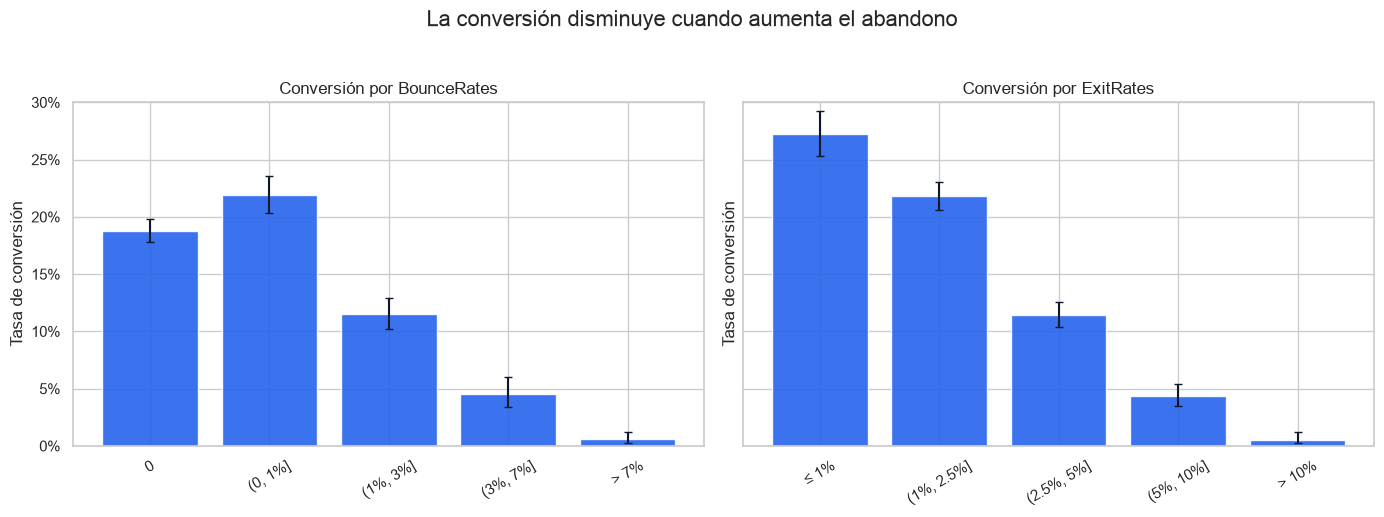

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_conversion(axes[0], bounce_conversion, 'Conversión por BounceRates')
plot_conversion(axes[1], exit_conversion, 'Conversión por ExitRates')
for axis in axes:
    axis.set_ylim(0, 0.30)
fig.suptitle('La conversión disminuye cuando aumenta el abandono', fontsize=16, y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'andres_eda_abandonment.png', dpi=160, bbox_inches='tight')
plt.show()

### Hallazgos de abandono

- Con `ExitRates` de hasta 1 %, la conversión alcanza **27,22 %**; por encima de 10 % cae a **0,54 %**. La relación descendente es consistente a través de todas las bandas.
- Para `BounceRates`, el máximo observado está en el intervalo (0, 1 %] (**21,91 %**) y luego la conversión cae hasta **0,58 %** cuando el rebote supera 7 %. Que el grupo exactamente igual a cero no sea el máximo advierte contra asumir una relación lineal simple.
- Ambas variables son señales fuertes de baja intención cuando toman valores altos. En modelamiento conviene conservar sus valores continuos y permitir relaciones no lineales, validando además que estén disponibles en el instante real de predicción.